# Regression Plot Comparison

Compare regression predictions across multiple checkpoints and render a publication-friendly multi-panel figure.

## 1) Setup

In [1]:
import os
import sys
import math
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figs'
CACHE_DIR = PROJECT_ROOT / 'notebooks' / 'figs_data'
FIG_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Plot Utility

In [10]:
def canonical_split_name(name: str) -> str:
    key = str(name).strip().lower()
    mapping = {
        'train': 'Train',
        'tr': 'Train',
        'val': 'Validation',
        'valid': 'Validation',
        'validation': 'Validation',
        'test': 'Test',
        'te': 'Test',
    }
    return mapping.get(key, str(name))


def ordered_segments(data_dict, split_order=('Train', 'Validation', 'Test')):
    normalized = []
    for label, (true_vals, pred_vals) in data_dict.items():
        normalized.append((canonical_split_name(label), np.asarray(true_vals), np.asarray(pred_vals)))

    ordered = []
    for split in split_order:
        ordered.extend([item for item in normalized if item[0] == split])
    ordered.extend([item for item in normalized if item[0] not in split_order])
    return ordered


def _panel_label_from_index(i: int) -> str:
    # 0 -> a, 1 -> b, ..., 25 -> z, 26 -> aa ...
    n = i + 1
    chars = []
    while n > 0:
        n, rem = divmod(n - 1, 26)
        chars.append(chr(ord('a') + rem))
    return f"({''.join(reversed(chars))})"


def plot_multiple_regression_series(
    data_dicts,
    titles=None,
    save_path=None,
    verbose=False,
    cols=2,
    figsize_per_col=6.4,
    figsize_per_row=3.8,
    linewidth=1.8,
    pred_linestyle='--',
    true_color='k',
    pred_color='tab:orange',
    split_order=('Train', 'Validation', 'Test'),
    split_facecolors=None,
    alpha_span=0.10,
    unify_ylim=True,
    ylim_pad=0.15,
    fontsize=10,
    title_fontsize=11,
    panel_label_fontsize=11,
    ncol_legend=4,
    show=True,
):
    if split_facecolors is None:
        split_facecolors = {
            'Train': 'tab:green',
            'Validation': 'tab:blue',
            'Test': 'tab:purple',
        }

    if len(data_dicts) == 0:
        raise ValueError('data_dicts is empty.')

    n = len(data_dicts)
    cols = min(cols, n)
    rows = math.ceil(n / cols)

    fig, axs = plt.subplots(
        rows,
        cols,
        figsize=(figsize_per_col * cols, figsize_per_row * rows),
        squeeze=False,
    )
    axs = axs.ravel()

    global_min, global_max = np.inf, -np.inf
    if unify_ylim:
        for data_dict in data_dicts:
            for _, true_vals, pred_vals in ordered_segments(data_dict, split_order=split_order):
                if len(true_vals) == 0:
                    continue
                global_min = min(global_min, float(np.min(true_vals)), float(np.min(pred_vals)))
                global_max = max(global_max, float(np.max(true_vals)), float(np.max(pred_vals)))

        if np.isfinite(global_min) and np.isfinite(global_max):
            global_min -= ylim_pad
            global_max += ylim_pad
        else:
            unify_ylim = False

    split_present = set()

    for i, data_dict in enumerate(data_dicts):
        ax = axs[i]
        idx_start = 0

        for split_name, true_vals, pred_vals in ordered_segments(data_dict, split_order=split_order):
            n_pts = len(true_vals)
            if n_pts == 0:
                continue

            idx_range = np.arange(idx_start, idx_start + n_pts)
            split_present.add(split_name)

            if split_name in split_facecolors:
                ax.axvspan(idx_start, idx_start + n_pts, color=split_facecolors[split_name], alpha=alpha_span, lw=0)

            ax.plot(idx_range, true_vals, color=true_color, lw=linewidth)
            ax.plot(idx_range, pred_vals, color=pred_color, lw=linewidth, ls=pred_linestyle)

            idx_start += n_pts

        ax.set_xlabel('Sample Index', fontsize=fontsize)
        ax.set_ylabel('Magnitude', fontsize=fontsize)
        if titles is not None and i < len(titles):
            ax.set_title(titles[i], fontsize=title_fontsize)
        ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.4)

        if unify_ylim:
            ax.set_ylim(global_min, global_max)

        panel_label = _panel_label_from_index(i)
        ax.text(
            0.015,
            0.98,
            panel_label,
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=panel_label_fontsize,
            fontweight='medium',
        )

    for j in range(n, len(axs)):
        axs[j].axis('off')

    legend_items = [
        Line2D([0], [0], color=true_color, lw=linewidth, label='True'),
        Line2D([0], [0], color=pred_color, lw=linewidth, ls=pred_linestyle, label='Predicted'),
    ]
    for split in split_order:
        if split in split_present and split in split_facecolors:
            legend_items.append(Patch(facecolor=split_facecolors[split], alpha=alpha_span, label=split))

    fig.legend(
        handles=legend_items,
        loc='lower center',
        ncol=min(ncol_legend, len(legend_items)),
        fontsize=fontsize,
        frameon=True,
    )

    fig.tight_layout(rect=[0, 0.08, 1, 1])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        if verbose:
            print(f'[Saved] {save_path}')

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig

## 3) Build `data_dicts` From Checkpoints

In [3]:
from src.train.config_setup import load_and_prepare_model
from src.data.preparation import prepare_data, prepare_data_lstm
from src.train.regressor_train_step import get_data_dict


def get_data_dicts_from_checkpoints(experiments, device):
    data_dicts = []
    titles = []
    loader_cache = {}

    for exp in experiments:
        checkpoint_path = Path(exp['checkpoint'])
        if not checkpoint_path.exists():
            raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

        model, args = load_and_prepare_model(
            checkpoint_path=checkpoint_path,
            device=device,
            compile=False,
        )

        prepare_fn = exp['prepare_fn']
        cache_key = (prepare_fn.__name__, args.dataset)

        if cache_key not in loader_cache:
            _, train_loader, val_loader, test_loader, _ = prepare_fn(
                base_dir=str(PROJECT_ROOT / 'data' / args.dataset),
                args=args,
            )
            loader_cache[cache_key] = (train_loader, val_loader, test_loader)

        train_loader, val_loader, test_loader = loader_cache[cache_key]
        data_dict = get_data_dict([train_loader, val_loader, test_loader], model, device)

        data_dicts.append(data_dict)
        titles.append(exp['title'])

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return data_dicts, titles

## 4) Experiment Config and Cache

In [4]:
EXPERIMENTS = [
    {
        'title': 'LSTM',
        'checkpoint': PROJECT_ROOT / 'checkpoints' / 'lstm_20260214-022353' / 'last_model_1.pth',
        'prepare_fn': prepare_data_lstm,
    },
    {
        'title': 'EM-EQF',
        'checkpoint': PROJECT_ROOT / 'checkpoints' / 'reg_mixer_attnpl_t_20260204-180531' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
    {
        'title': r'EM-EQF (+$\log(\Delta t)$)',
        'checkpoint': PROJECT_ROOT / 'checkpoints' / 'reg_mixer_attnpl_t_20260204-195612' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
    {
        'title': 'EM-EQF (-T-XPOS)',
        'checkpoint': PROJECT_ROOT / 'checkpoints' / 'reg_mixer_attnpl_t_20260204-201607' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
    {
        'title': 'EM-EQF (-TMAP)',
        'checkpoint': PROJECT_ROOT / 'checkpoints' / 'reg_mixer_attnpl_t_20260204-194201' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
    {
        'title': 'EM-EQF (-Pretrain)',
        'checkpoint': PROJECT_ROOT / 'checkpoints' / 'reg_mixer_attnpl_t_20260204-192629' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
]

CACHE_PATH = CACHE_DIR / 'reg_data_dicts.pkl'
USE_CACHE = False
SAVE_CACHE = True

if USE_CACHE and CACHE_PATH.exists():
    with open(CACHE_PATH, 'rb') as f:
        cached = pickle.load(f)

    if isinstance(cached, dict):
        data_dicts = cached['data_dicts']
        titles = cached.get('titles', [exp['title'] for exp in EXPERIMENTS])
    else:
        data_dicts = cached
        titles = [exp['title'] for exp in EXPERIMENTS][:len(data_dicts)]

    print(f'Loaded cached data_dicts from: {CACHE_PATH}')
else:
    data_dicts, titles = get_data_dicts_from_checkpoints(EXPERIMENTS, DEVICE)

    if SAVE_CACHE:
        with open(CACHE_PATH, 'wb') as f:
            pickle.dump({'data_dicts': data_dicts, 'titles': titles}, f)
        print(f'Saved data_dicts to: {CACHE_PATH}')

print(f'Number of experiments: {len(data_dicts)}')
for title, data_dict in zip(titles, data_dicts):
    print(f'- {title}: {list(data_dict.keys())}')

Saved data_dicts to: /root/autodl-tmp/em_eqf/notebooks/figs_data/reg_data_dicts.pkl
Number of experiments: 6
- LSTM: ['Train', 'Validation', 'Test']
- EM-EQF: ['Train', 'Validation', 'Test']
- EM-EQF (+$\log(\Delta t)$): ['Train', 'Validation', 'Test']
- EM-EQF (-T-XPOS): ['Train', 'Validation', 'Test']
- EM-EQF (-TMAP): ['Train', 'Validation', 'Test']
- EM-EQF (-Pretrain): ['Train', 'Validation', 'Test']


## 5) Plot

[Saved] /root/autodl-tmp/em_eqf/notebooks/figs/regression_plots.pdf


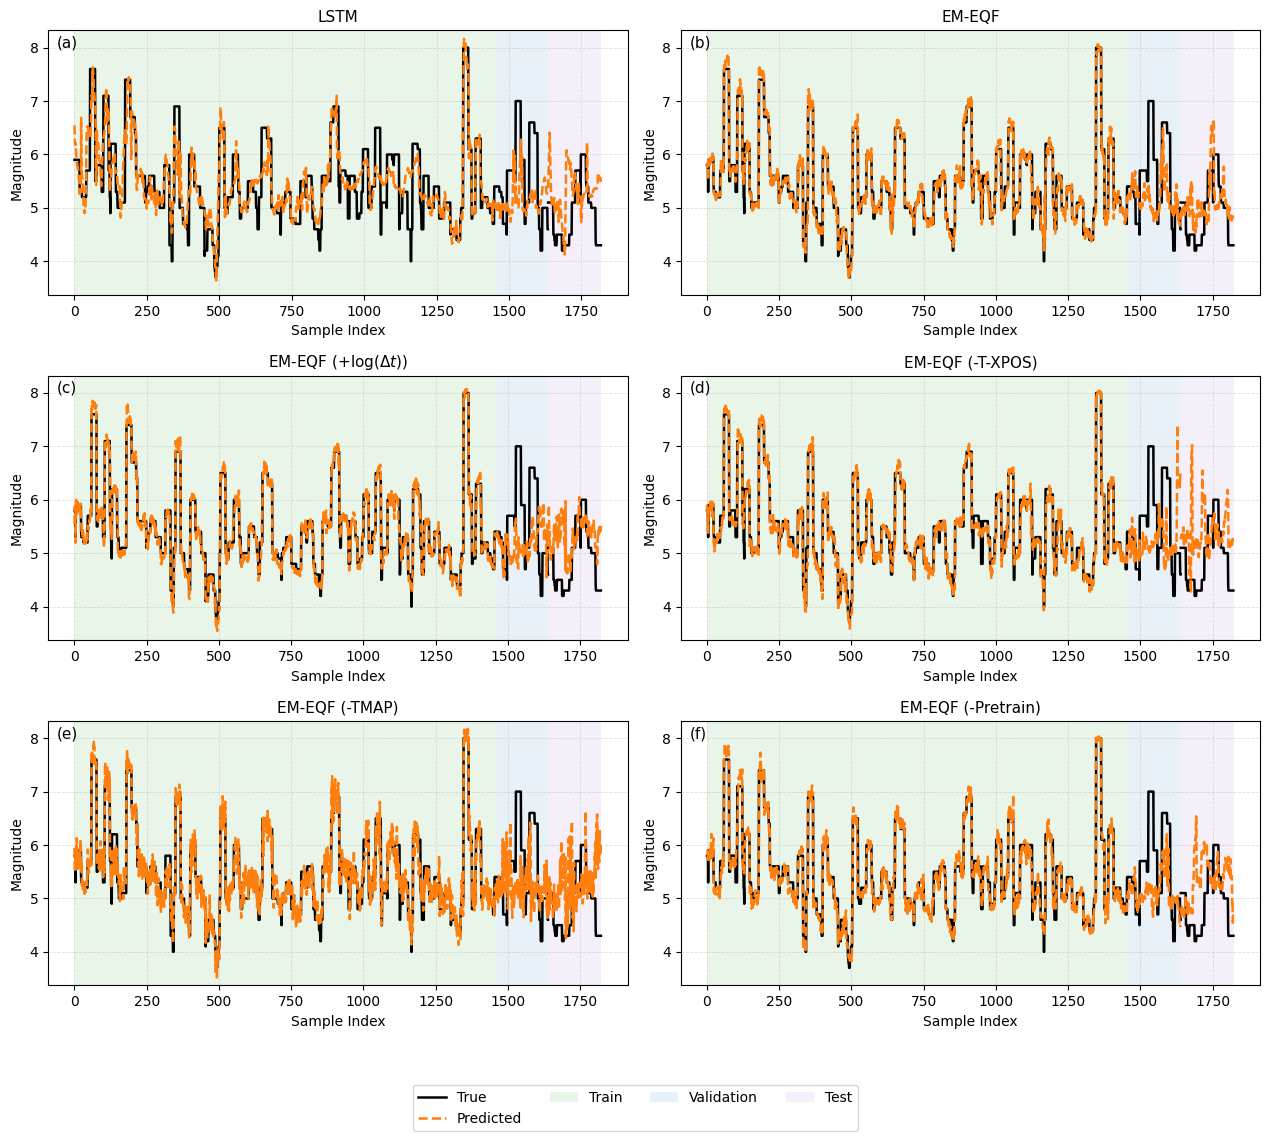

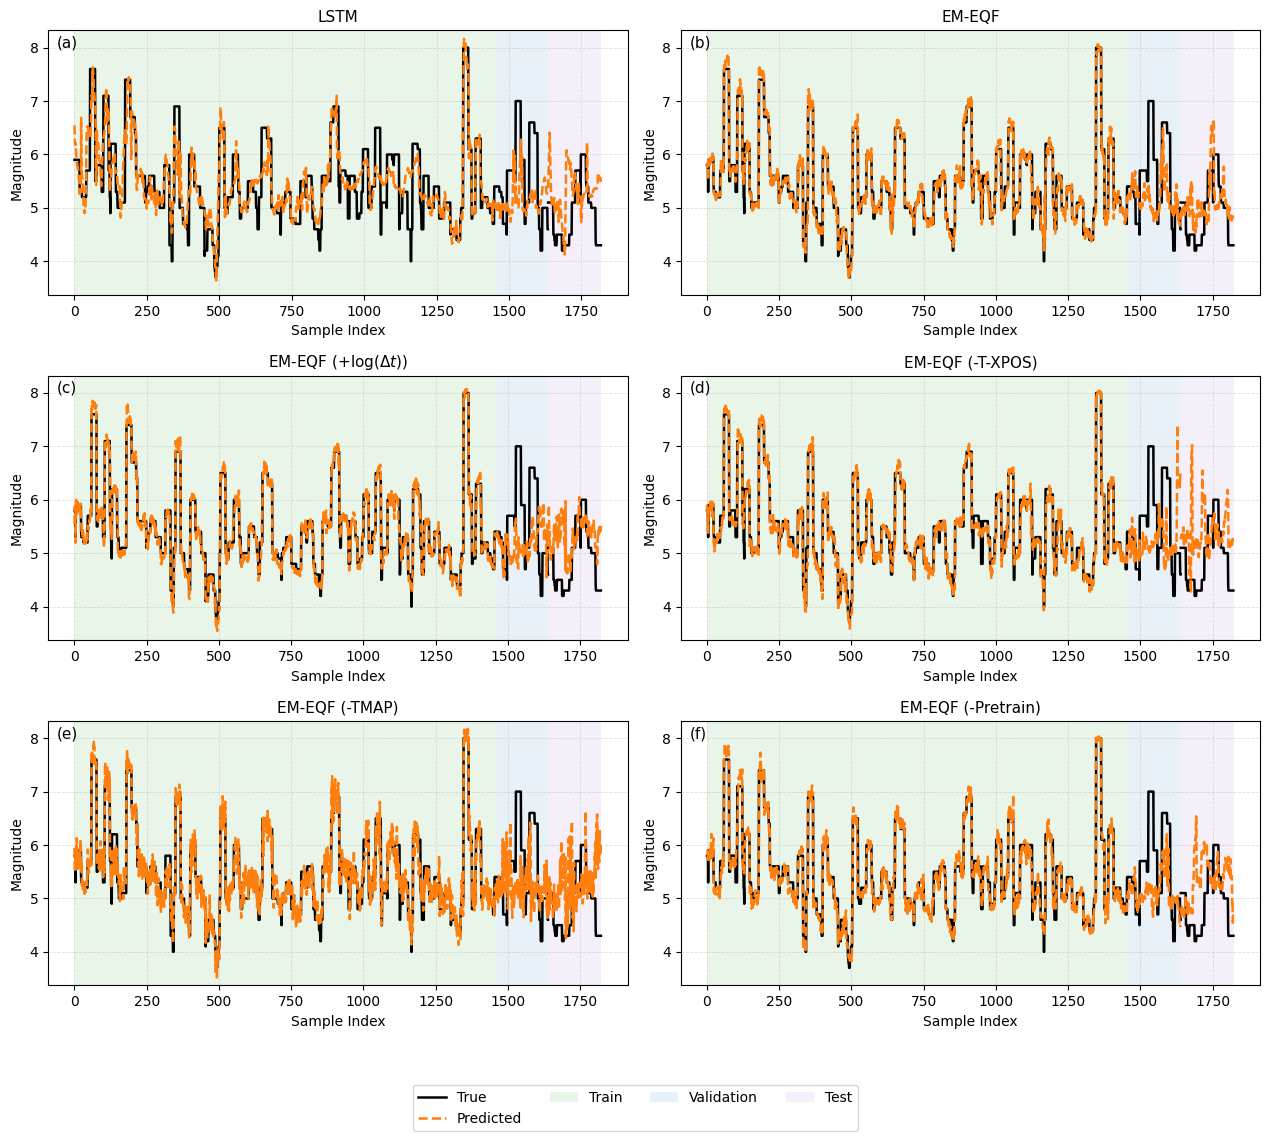

In [11]:
OUTPUT_PATH = FIG_DIR / 'regression_plots.pdf'

plot_multiple_regression_series(
    data_dicts=data_dicts,
    titles=titles,
    save_path=str(OUTPUT_PATH),
    verbose=True,
)